In [1]:
# get root path and add to sys.path
import os
import sys
from pathlib import Path

root_path = Path().absolute().parent.parent
sys.path.append(str(root_path))


import json
from functions.sqldatabase_langchain_utils import SQLDatabaseLangchainUtils

experiment = "kaggle"

with open(root_path / f"connections/{experiment}_db_connection.json", "r") as f:
    db_connection = json.load(f)

include_tables = [
    "geonucleardata_nuclear_power_plants",
    "greatermanchestercrime_greatermanchestercrime",
    "pesticide_resultsdata15",
    "pesticide_sampledata15",
    "studentmathscore_finrev_fed_17",
    "studentmathscore_finrev_fed_key_17",
    "studentmathscore_ndecoreexcel_math_grade8",
    "thehistoryofbaseball_hall_of_fame",
    "thehistoryofbaseball_player",
    "thehistoryofbaseball_player_award",
    "thehistoryofbaseball_player_award_vote",
    "thehistoryofbaseball_salary",
    "uswildfires_fires",
    "whatcdhiphop_tags",
    "whatcdhiphop_torrents",
    "worldsoccerdatabase_betfront",
    "worldsoccerdatabase_football_data"
]

samples = 3
view_support = False

db = SQLDatabaseLangchainUtils(db_connection=db_connection, include_tables=include_tables, samples=samples, view_support=view_support)

table_info = db.get_table_info().replace('"KAGGLE".', "")

In [2]:
print(table_info)


CREATE TABLE geonucleardata_nuclear_power_plants (
	id NUMBER NOT NULL, 
	name VARCHAR(200 CHAR), 
	latitude NUMBER(9, 6), 
	longitude NUMBER(9, 6), 
	country VARCHAR(100 CHAR), 
	status VARCHAR(50 CHAR), 
	reactortype VARCHAR(50 CHAR), 
	reactormodel VARCHAR(200 CHAR), 
	constructionstartat DATE, 
	operationalfrom DATE, 
	operationalto DATE, 
	capacity NUMBER, 
	lastupdatedat TIMESTAMP WITH TIME ZONE, 
	source VARCHAR(100 CHAR), 
	CONSTRAINT sys_c004738160 PRIMARY KEY (id)
)
 TABLESPACE "KAGGLE"

/*
3 rows from geonucleardata_nuclear_power_plants table:
id	name	latitude	longitude	country	status	reactortype	reactormodel	constructionstartat	operationalfrom	operationalto	capacity	lastupdatedat	source
450.0	Maanshan-2	25.038	121.924	Taiwan, Province of China	Operational	PWR	WH 3LP (WE 312)	1979-02-21 00:00:00	1985-05-18 00:00:00	None	890.0	2017-02-10 23:57:34	WNA/IAEA
451.0	Maine Yankee	43.951	-69.695	United States	Shutdown	PWR	None	1968-10-01 00:00:00	1972-12-28 00:00:00	1997-08-01 00:0

In [3]:
def structured_table_info(table_info):
    """
    Função que recebe a string de informações da tabela e 
    """
    tables_dict = {}
    
    # Split the table_info by CREATE TABLE to identify each table definition
    table_blocks = table_info.split("CREATE TABLE ")
    
    for block in table_blocks:
        if not block.strip():
            continue

        # Extract table name
        table_name = block.split('(')[0].strip()

        tables_dict[table_name] = "CREATE TABLE " + block
        
    return tables_dict

table_ddls_hashmap = structured_table_info(table_info)
print(table_ddls_hashmap["geonucleardata_nuclear_power_plants"])

CREATE TABLE geonucleardata_nuclear_power_plants (
	id NUMBER NOT NULL, 
	name VARCHAR(200 CHAR), 
	latitude NUMBER(9, 6), 
	longitude NUMBER(9, 6), 
	country VARCHAR(100 CHAR), 
	status VARCHAR(50 CHAR), 
	reactortype VARCHAR(50 CHAR), 
	reactormodel VARCHAR(200 CHAR), 
	constructionstartat DATE, 
	operationalfrom DATE, 
	operationalto DATE, 
	capacity NUMBER, 
	lastupdatedat TIMESTAMP WITH TIME ZONE, 
	source VARCHAR(100 CHAR), 
	CONSTRAINT sys_c004738160 PRIMARY KEY (id)
)
 TABLESPACE "KAGGLE"

/*
3 rows from geonucleardata_nuclear_power_plants table:
id	name	latitude	longitude	country	status	reactortype	reactormodel	constructionstartat	operationalfrom	operationalto	capacity	lastupdatedat	source
450.0	Maanshan-2	25.038	121.924	Taiwan, Province of China	Operational	PWR	WH 3LP (WE 312)	1979-02-21 00:00:00	1985-05-18 00:00:00	None	890.0	2017-02-10 23:57:34	WNA/IAEA
451.0	Maine Yankee	43.951	-69.695	United States	Shutdown	PWR	None	1968-10-01 00:00:00	1972-12-28 00:00:00	1997-08-01 00:00

In [4]:
table_ddls_hashmap

{'geonucleardata_nuclear_power_plants': 'CREATE TABLE geonucleardata_nuclear_power_plants (\n\tid NUMBER NOT NULL, \n\tname VARCHAR(200 CHAR), \n\tlatitude NUMBER(9, 6), \n\tlongitude NUMBER(9, 6), \n\tcountry VARCHAR(100 CHAR), \n\tstatus VARCHAR(50 CHAR), \n\treactortype VARCHAR(50 CHAR), \n\treactormodel VARCHAR(200 CHAR), \n\tconstructionstartat DATE, \n\toperationalfrom DATE, \n\toperationalto DATE, \n\tcapacity NUMBER, \n\tlastupdatedat TIMESTAMP WITH TIME ZONE, \n\tsource VARCHAR(100 CHAR), \n\tCONSTRAINT sys_c004738160 PRIMARY KEY (id)\n)\n TABLESPACE "KAGGLE"\n\n/*\n3 rows from geonucleardata_nuclear_power_plants table:\nid\tname\tlatitude\tlongitude\tcountry\tstatus\treactortype\treactormodel\tconstructionstartat\toperationalfrom\toperationalto\tcapacity\tlastupdatedat\tsource\n450.0\tMaanshan-2\t25.038\t121.924\tTaiwan, Province of China\tOperational\tPWR\tWH 3LP (WE 312)\t1979-02-21 00:00:00\t1985-05-18 00:00:00\tNone\t890.0\t2017-02-10 23:57:34\tWNA/IAEA\n451.0\tMaine Yank

In [5]:
from typing import List
from pydantic import BaseModel, Field
from functions.llm_config import LLMConfig

class Join(BaseModel):
    from_: str = Field(..., alias="from", description="Origin table of the join")
    to: str = Field(..., description="Destiny table of the join")
    on: List[str] = Field(..., description="Fully qualified join conditions in the format 'TABLE1.COLUMN1=TABLE2.COLUMN2'")
    
class FirstStepOutputFormat(BaseModel):
    joins: List[Join] = Field(..., description="List of possible joins between tables")
    
# Inicializar o modelo de linguagem para a extração dos joins
llm = LLMConfig(provider="azure").get_llm(model="gpt-4o")
llm_with_structured_output = llm.with_structured_output(FirstStepOutputFormat)

In [10]:
from tqdm import tqdm

FULL_SCHEMA = table_info

joins = []

for table in tqdm(table_ddls_hashmap, desc="\nFinding join combinations..."):
    prompt = """
Given the schema of the database, generate all possible join combinations between table i'll give you and the other tables in schema. Use PK and FK informations for that, and consider that the tables are connected by a single join.

Be very careful with composed keys, they are a combination of two or more columns that are used to reference another table.

For each join condition, use the fully qualified column name format: 'TABLE1.COLUMN1=TABLE2.COLUMN2'

Examples of the required format:
- For a simple join: 
  Join(from_='DATABASE_TABLE_1', to='DATABASE_TABLE_2', on=['DATABASE_TABLE_2.FK_COLUMN=DATABASE_TABLE_1.PK_COLUMN'])

- For a compound join:
  Join(from_='DATABASE_TABLE_1', to='DATABASE_TABLE_2', on=['DATABASE_TABLE_2.FK_COLUMN=DATABASE_TABLE_1.PK_COLUMN'])

# Full Schema:
{full_schema}
 
# Target table:
{target_table}

BE CAREFUL TO NOT MISS ANY JOIN, AND DON'T CREATE A JOIN THAT DOESN'T EXIST IN THE SCHEMA. ALSO DON'T FORGET ANY TABLE IN THE SCHEMA.
BE AWARE THAT THE TABLES USWILDFIRES_FIRES, GEONUCLEARDATA_NUCLEAR_POWER_PLANTS AND GREATERMANCHESTERCRIME_GREATERMANCHESTERCRIME DON'T HAVE ANY JOIN WITH OTHER TABLES.
Structured Output:
"""
    prompt_with_schema = prompt.format(full_schema=FULL_SCHEMA, target_table=table_ddls_hashmap[table])

    result = llm_with_structured_output.invoke(prompt_with_schema)
    
    for join in result.joins:
        joins.append(join)


Finding join combinations...: 100%|██████████| 17/17 [00:35<00:00,  2.11s/it]


In [11]:
# Create a dictionary to track unique joins
seen_joins = {}
unique_joins = []

# Function to normalize join conditions for comparison
def normalize_join(join):
    # Create a canonical representation of the join
    # Sort conditions and normalize table order
    from_table = join.from_
    to_table = join.to
    
    # Normalize the join conditions
    normalized_conditions = []
    for condition in join.on:
        # Split the condition into left and right parts
        parts = condition.split('=')
        left = parts[0].strip()
        right = parts[1].strip()
        
        # Extract table names from the conditions
        left_table = left.split('.')[0]
        right_table = right.split('.')[0]
        
        # Ensure consistent ordering of tables in the condition
        if left_table > right_table:
            normalized_conditions.append(f"{right}={left}")
        else:
            normalized_conditions.append(f"{left}={right}")
    
    # Sort the normalized conditions
    normalized_conditions.sort()
    
    # Create a key with tables sorted alphabetically
    tables = sorted([from_table, to_table])
    return (tables[0], tables[1], tuple(normalized_conditions))

# Count original joins
original_count = len(joins)

# Filter out duplicate joins
for join in joins:
    key = normalize_join(join)
    if key not in seen_joins:
        seen_joins[key] = join
        unique_joins.append(join)

# Replace the original joins list with unique joins
joins = unique_joins

print(f"Removed {original_count - len(unique_joins)} duplicate joins")


Removed 48 duplicate joins


Grafo construído com 14 tabelas e 16 joins possíveis
Total de tabelas no esquema: 14
Primeiras 10 tabelas: ['pesticide_resultsdata15', 'pesticide_sampledata15', 'studentmathscore_finrev_fed_17', 'studentmathscore_finrev_fed_key_17', 'thehistoryofbaseball_hall_of_fame', 'thehistoryofbaseball_player', 'thehistoryofbaseball_player_award', 'thehistoryofbaseball_player_award_vote', 'thehistoryofbaseball_salary', 'whatcdhiphop_tags']


/tmp/ipykernel_2991/3799037941.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


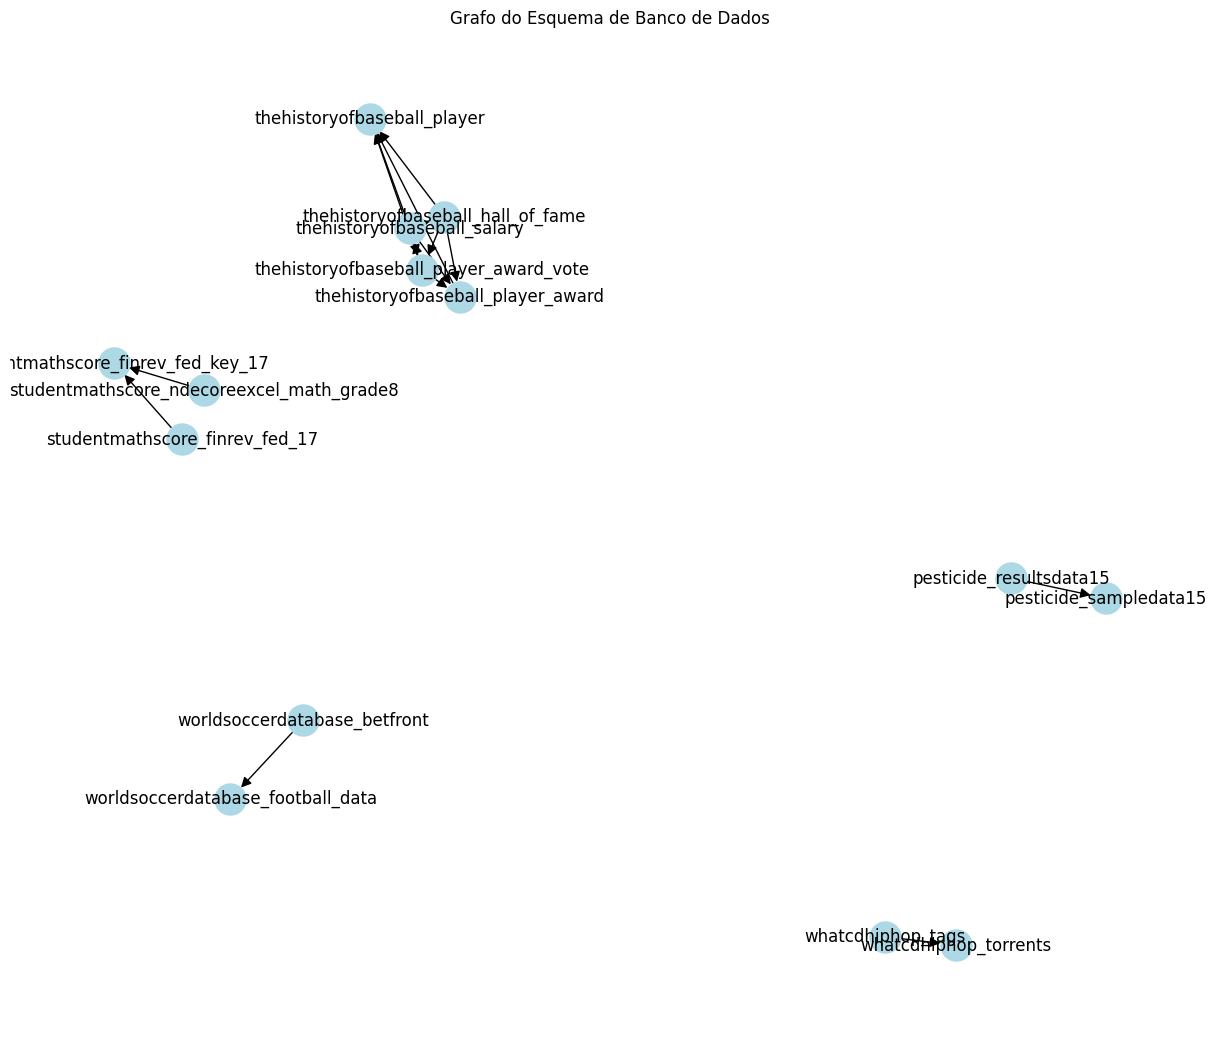

In [12]:
# Célula 1: Construir grafo de tabelas e joins
import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import Counter, defaultdict
import pandas as pd

def build_schema_graph(joins):
    """
    Constrói um grafo representando o esquema do banco de dados.
    - Nós: tabelas
    - Arestas: joins entre tabelas
    """
    G = nx.DiGraph()
    
    # Adicionar todas as tabelas como nós
    for join in joins:
        G.add_node(join.from_)
        G.add_node(join.to)
        # Adicionar aresta direcional com os detalhes do join
        G.add_edge(join.from_, join.to, conditions=join.on, join_obj=join)
    
    # Imprimir estatísticas do grafo
    print(f"Grafo construído com {G.number_of_nodes()} tabelas e {G.number_of_edges()} joins possíveis")
    
    return G

# Construir o grafo
schema_graph = build_schema_graph(joins)

# Verificar todas as tabelas no grafo
all_tables = list(schema_graph.nodes())
print(f"Total de tabelas no esquema: {len(all_tables)}")
print(f"Primeiras 10 tabelas: {all_tables[:10]}")

# Visualizar o grafo (opcional, pode ser comentado se o grafo for muito grande)
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(schema_graph, seed=42)  # Posicionamento para visualização
nx.draw(schema_graph, pos, with_labels=True, node_color='lightblue', 
        node_size=500, arrows=True, arrowsize=15)
plt.title("Grafo do Esquema de Banco de Dados")
plt.tight_layout()
plt.show()

Grafo construído com 40 tabelas e 195 joins possíveis
Total de tabelas no esquema: 40
Primeiras 10 tabelas: ['mondial_airport', 'mondial_city', 'mondial_country', 'mondial_geo_island', 'mondial_locatedon', 'mondial_borders', 'mondial_countrypops', 'mondial_economy', 'mondial_encompasses', 'mondial_ethnicgroup']

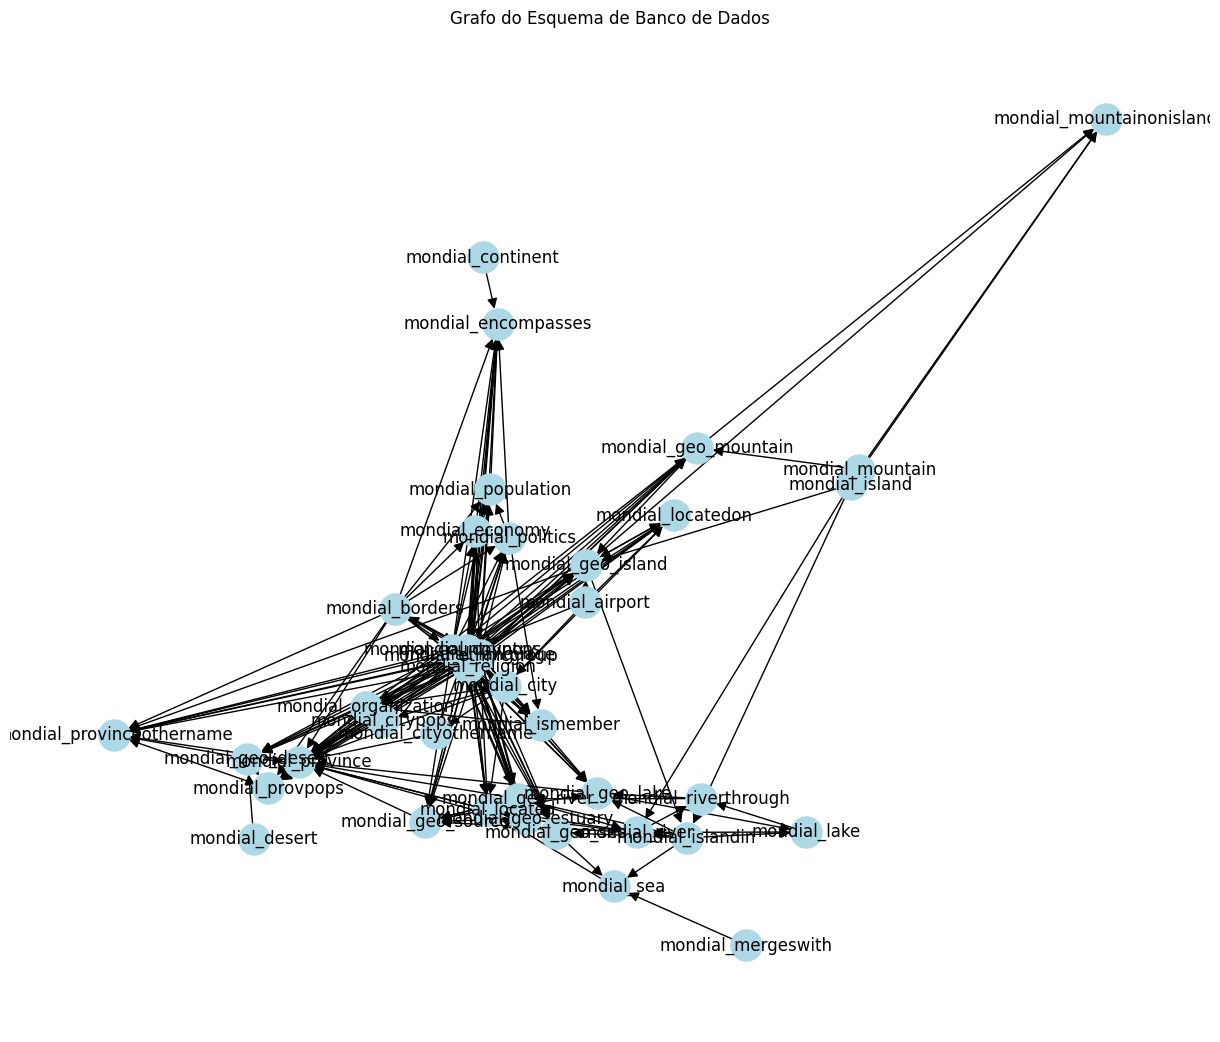

[Graph] Tabelas: 14 | Joins possíveis (edges): 16
[Coverage] Could not reach 100%. Current: 71.43%

=== Final Results ===
Total combos: 28
 Type 2: 13 combos
 Type 3: 11 combos
 Type 4: 4 combos
Coverage: 71.43%  | 10/14 tables used.

Mean frequency: 5.93
Median frequency: 1.50


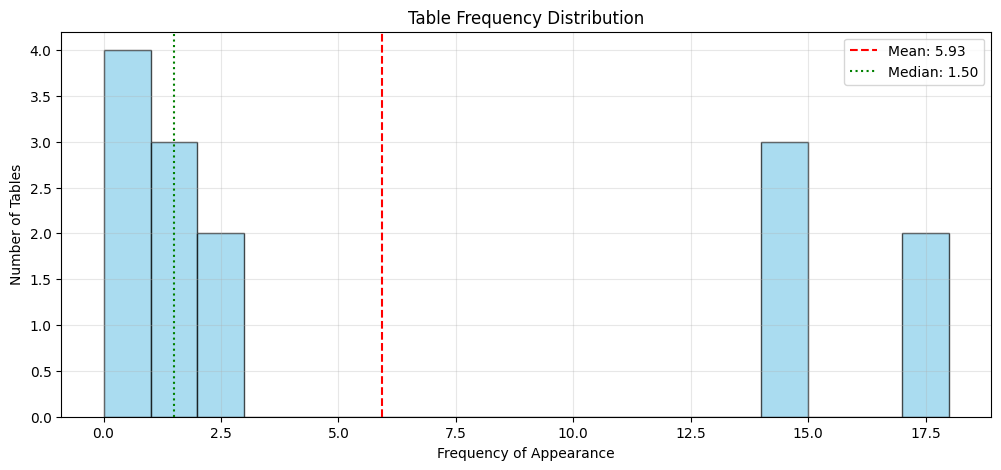

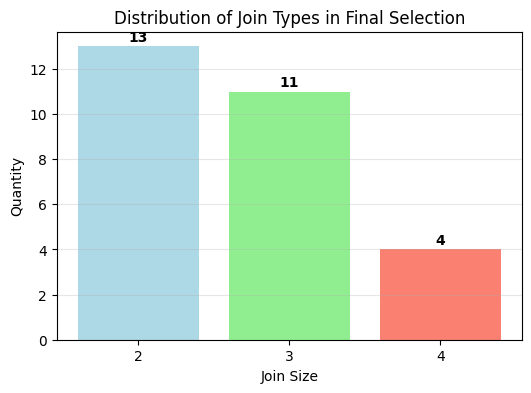

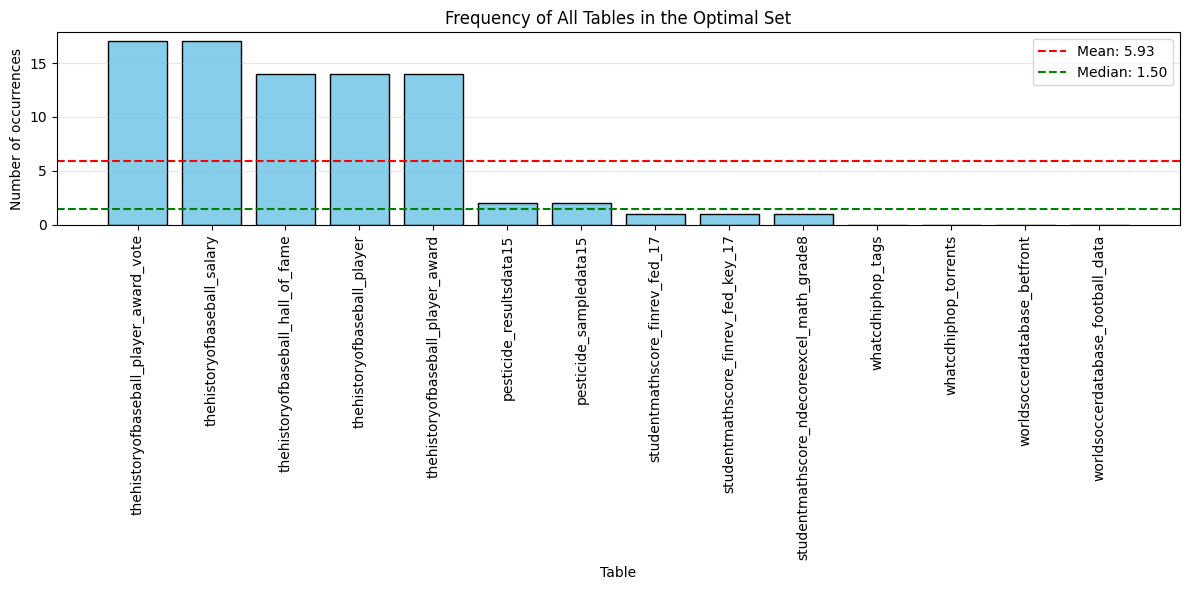

Saved optimal join combinations to joins/join_combinations.csv


In [13]:
# ============================
# CÉLULA ÚNICA: FLUXO COMPLETO
# ============================

import networkx as nx
import matplotlib.pyplot as plt
import random
from collections import defaultdict
import itertools
import numpy as np
import statistics
import os
from pathlib import Path

###############################################################################
# PASSO 1: BUILD SCHEMA GRAPH
###############################################################################
def build_schema_graph(joins):
    """
    Constrói um grafo representando o esquema do banco de dados.
    Nós = tabelas
    Arestas = joins entre tabelas
    """
    G = nx.DiGraph()
    for join in joins:
        G.add_node(join.from_)
        G.add_node(join.to)
        G.add_edge(join.from_, join.to, conditions=join.on, join_obj=join)
    print(f"[Graph] Tabelas: {G.number_of_nodes()} | Joins possíveis (edges): {G.number_of_edges()}")
    return G

###############################################################################
# PASSO 2: GERA TODAS AS COMBINAÇÕES 2,3,4 QUE SEJAM CONEXAS
###############################################################################
def is_connected_subgraph(join_set):
    """
    Verifica se o conjunto de joins forma um subgrafo conexo (não-dirigido).
    """
    if not join_set:
        return False
    # Para 1 join somente, consideramos conectado
    if len(join_set) == 1:
        return True
    
    tables = set()
    for j in join_set:
        tables.add(j.from_)
        tables.add(j.to)
    
    # Montamos um grafo não-dirigido
    graph = {t: set() for t in tables}
    for j in join_set:
        graph[j.from_].add(j.to)
        graph[j.to].add(j.from_)
    
    visited = set()
    queue = [next(iter(tables))]
    visited.add(queue[0])
    
    while queue:
        node = queue.pop(0)
        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)
    
    return len(visited) == len(tables)

def prepare_all_combinations(joins, max_size=4):
    """
    Gera todas as combinações possíveis de 2, 3, 4 joins que sejam conexas.
    Retorna { '2': [...], '3': [...], '4': [...] }.
    """
    combos_by_type = {"2": [], "3": [], "4": []}
    for size in [2, 3, 4]:
        if size > max_size:
            continue
        all_subsets = list(itertools.combinations(joins, size))
        valid = []
        for sset in all_subsets:
            if is_connected_subgraph(sset):
                valid.append(sset)
        combos_by_type[str(size)] = valid
    return combos_by_type

###############################################################################
# PASSO 3: SELEÇÃO DAS COMBINAÇÕES PRIORIZANDO COBERTURA=100%, BALANCE (2,3,4),
#          MÍNIMO n, E FREQUÊNCIA DE TABELAS.
###############################################################################
def get_join_type(comb):
    """
    Retorna '2','3','4' baseado no número de tabelas distintas em 'comb'.
    """
    tables = set()
    for j in comb:
        tables.add(j.from_)
        tables.add(j.to)
    tcount = len(tables)
    if tcount <= 2:
        return "2"
    elif tcount == 3:
        return "3"
    else:
        return "4"

def is_redundant(new_comb, existing_list, threshold=0.75):
    """
    Diz se new_comb é redundante frente a 'existing_list' de combos,
    se a sobreposição de tabelas >= threshold.
    """
    new_tables = set()
    for j in new_comb:
        new_tables.add(j.from_)
        new_tables.add(j.to)
    
    for comb in existing_list:
        c_tables = set()
        for jj in comb:
            c_tables.add(jj.from_)
            c_tables.add(jj.to)
        inter = len(new_tables.intersection(c_tables))
        uni = len(new_tables.union(c_tables))
        if uni == 0:
            continue
        if (inter/uni) >= threshold:
            return True
    return False

def select_balanced_combinations(
    combos_by_type, 
    all_tables, 
    min_n=30, 
    coverage_first=True
    ):
    """
    Seleciona combinações, priorizando:
    1) Cobertura 100% se coverage_first = True
    2) Equilíbrio de tipos (2,3,4)
    3) Atingir ao menos min_n combinações
    4) Frequência das tabelas (com peso menor)
    
    combos_by_type: dicionário { '2': [...], '3': [...], '4': [...] } 
    """
    selected = {"2": [], "3": [], "4": []}
    table_freq = {t: 0 for t in all_tables}
    tables_covered = set()
    
    def coverage_percent():
        return (len(tables_covered)/len(all_tables)) * 100.0
    
    def count_total():
        return sum(len(selected[t]) for t in ["2","3","4"])
    
    # Define pontuação para combo
    def combo_score(comb):
        c_tables = set()
        for j in comb:
            c_tables.add(j.from_)
            c_tables.add(j.to)
        
        # Prioriza adicionar novas tabelas se coverage < 100
        new_tables = 0
        freq_penalty = 0
        for tab in c_tables:
            if tab not in tables_covered:
                new_tables += 1
            else:
                # penaliza um pouco tabelas já muito frequentes
                if table_freq[tab] > 2:
                    freq_penalty += (table_freq[tab] - 2)**2
        
        # Score final
        return new_tables*20 - freq_penalty
    
    # Fase 1: Cobertura, se coverage_first
    coverage_done = (coverage_percent() >= 100.0)
    iters_no_progress = 0
    max_iters = 50
    
    while (coverage_first and not coverage_done) and iters_no_progress < max_iters:
        best_c = None
        best_type = None
        best_s = float('-inf')
        
        for t in ["2","3","4"]:
            for comb in combos_by_type[t]:
                if comb in selected[t]:
                    continue
                if is_redundant(comb, selected[t]):
                    continue
                sc = combo_score(comb)
                if sc > best_s:
                    best_s = sc
                    best_c = comb
                    best_type = t
        
        if best_c is None:
            iters_no_progress += 1
        else:
            selected[best_type].append(best_c)
            c_tables = set()
            for j in best_c:
                c_tables.add(j.from_)
                c_tables.add(j.to)
            for tab in c_tables:
                table_freq[tab]+=1
                tables_covered.add(tab)
            iters_no_progress = 0
        
        coverage_done = (coverage_percent() >= 100.0)
    
    if coverage_done:
        print(f"[Coverage] Achieved 100% coverage with {count_total()} combos.")
    else:
        print(f"[Coverage] Could not reach 100%. Current: {coverage_percent():.2f}%")
    
    # Fase 2: Balance de tipos e min_n
    attempts_no_improv = 0
    while count_total() < min_n and attempts_no_improv < 30:
        # Identifica o tipo sub-representado
        type_counts = {t: len(selected[t]) for t in ["2","3","4"]}
        total_c = sum(type_counts.values())
        if total_c == 0:
            # se não há nada ainda, prioriza 2
            sub_type = "2"
        else:
            sub_type = min(type_counts, key=type_counts.get)
        
        best_c = None
        best_score_ = float('-inf')
        
        for comb in combos_by_type[sub_type]:
            if comb in selected[sub_type]:
                continue
            if is_redundant(comb, selected[sub_type]):
                continue
            sc = combo_score(comb)
            if sc > best_score_:
                best_score_ = sc
                best_c = comb
        
        if best_c is None:
            # tentar outro tipo
            found_something = False
            for alt_type in ["2","3","4"]:
                if alt_type == sub_type:
                    continue
                alt_best = None
                alt_bs = float('-inf')
                for comb in combos_by_type[alt_type]:
                    if comb in selected[alt_type]:
                        continue
                    if is_redundant(comb, selected[alt_type]):
                        continue
                    sc = combo_score(comb)
                    if sc> alt_bs:
                        alt_bs= sc
                        alt_best= comb
                if alt_best:
                    selected[alt_type].append(alt_best)
                    c_tables = set()
                    for j in alt_best:
                        c_tables.add(j.from_)
                        c_tables.add(j.to)
                    for tb in c_tables:
                        table_freq[tb]+=1
                        tables_covered.add(tb)
                    found_something = True
                    break
            if not found_something:
                attempts_no_improv+=1
        else:
            selected[sub_type].append(best_c)
            c_tables = set()
            for j in best_c:
                c_tables.add(j.from_)
                c_tables.add(j.to)
            for tb in c_tables:
                table_freq[tb]+=1
                tables_covered.add(tb)
            attempts_no_improv= 0
    
    # Retorna 
    return selected, table_freq, tables_covered

###############################################################################
# PASSO 4: PLOT E SUMÁRIO
###############################################################################
def summarize_and_plot_results(selected, table_freq, all_tables):
    """
    Exibe sumário e gera gráficos:
      - Frequência de cada tabela (histograma com média e mediana)
      - Distribuição de tipos (barras)
    """
    type_counts = {t: len(selected[t]) for t in ["2","3","4"]}
    total_combos = sum(type_counts.values())
    
    print("\n=== Final Results ===")
    print(f"Total combos: {total_combos}")
    for t in ["2","3","4"]:
        print(f" Type {t}: {type_counts[t]} combos")
    
    used_tables = [t for t, f in table_freq.items() if f>0]
    coverage= len(used_tables)/len(all_tables)*100
    print(f"Coverage: {coverage:.2f}%  | {len(used_tables)}/{len(all_tables)} tables used.\n")
    
    freq_values= list(table_freq.values())
    mean_f= np.mean(freq_values) if freq_values else 0
    median_f= statistics.median(freq_values) if freq_values else 0
    
    print(f"Mean frequency: {mean_f:.2f}")
    print(f"Median frequency: {median_f:.2f}")
    
    # Grafico 1: Histograma de frequência
    plt.figure(figsize=(12,5))
    if freq_values:
        max_f= max(freq_values)
        bins= range(0, max_f+2)
        plt.hist(freq_values, bins=bins, alpha=0.7, color='skyblue', edgecolor='black')
        plt.axvline(x=mean_f, color='red', linestyle='--', label=f'Mean: {mean_f:.2f}')
        plt.axvline(x=median_f, color='green', linestyle=':', label=f'Median: {median_f:.2f}')
    plt.title("Table Frequency Distribution")
    plt.xlabel("Frequency of Appearance")
    plt.ylabel("Number of Tables")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    
    # Grafico 2: Distribuicao por tipo
    plt.figure(figsize=(6,4))
    sizes= ["2","3","4"]
    counts= [type_counts[s] for s in sizes]
    
    bars= plt.bar(sizes, counts, color=['lightblue','lightgreen','salmon'])
    for i, c in enumerate(counts):
        plt.text(i, c+0.1, str(c), ha='center', va='bottom', fontweight='bold')
    
    plt.title("Distribution of Join Types in Final Selection")
    plt.xlabel("Join Size")
    plt.ylabel("Quantity")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

import numpy as np
import statistics
import matplotlib.pyplot as plt

def plot_all_table_frequencies(table_freq, title="Frequency of All Tables in Combinations"):
    """
    Gera um gráfico de barras mostrando a frequência de cada tabela.
    As tabelas são ordenadas em ordem decrescente de frequência.
    Adiciona linhas horizontais indicando média e mediana.
    
    Args:
        table_freq (dict): dicionário {nome_tabela: freq_de_ocorrencia}
        title (str): título do gráfico (opcional)
    """
    
    # 1. Ordenar as tabelas por frequência (decrescente)
    sorted_items = sorted(table_freq.items(), key=lambda x: x[1], reverse=True)
    table_names = [item[0] for item in sorted_items]
    frequencies = [item[1] for item in sorted_items]
    
    # 2. Calcular média e mediana (se a lista estiver vazia, definimos 0)
    if frequencies:
        mean_freq = np.mean(frequencies)
        median_freq = statistics.median(frequencies)
    else:
        mean_freq, median_freq = 0, 0
    
    # 3. Criar figura e plotar barras
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(table_names)), frequencies, color='skyblue', edgecolor='black')
    
    # 4. Linhas horizontais: média (vermelho) e mediana (verde)
    plt.axhline(y=mean_freq, color='red', linestyle='--', label=f'Mean: {mean_freq:.2f}')
    plt.axhline(y=median_freq, color='green', linestyle='--', label=f'Median: {median_freq:.2f}')
    
    # 5. Labels e estilização
    plt.title(title)
    plt.xlabel("Table")
    plt.ylabel("Number of occurrences")
    plt.xticks(range(len(table_names)), table_names, rotation=90)
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()  # Ajusta espaçamentos para não cortar legendas
    
    # Exibir ou salvar
    plt.show()

# Exemplo de uso (em outra célula ou no final do código):
# plot_all_table_frequencies(table_freq, "Frequency of All Tables in the Optimal Set")

def save_optimal_join_combinations(selected, output_path='joins/join_combination/optimal_join_combinations.csv'):
    """
    Saves the optimal join combinations to a CSV file.
    
    Args:
        selected (dict): Dictionary with keys '2', '3', '4' mapping to lists of join combinations
        output_path (str): Path where the CSV file will be saved
    """
    import pandas as pd
    
    # Create lists to store data
    types = []
    combination_ids = []
    tables_list = []
    join_conditions = []
    
    # For each type of join (2, 3, 4)
    for join_type in ["2", "3", "4"]:
        # For each combination in that type
        for i, combo in enumerate(selected[join_type], 1):
            # Get all unique tables in this combination
            tables = set()
            for join in combo:
                tables.add(join.from_)
                tables.add(join.to)
            
            # Format join conditions
            conditions = []
            for join in combo:
                if hasattr(join, 'on') and join.on:
                    conditions.append(f"{join.from_}.{join.on}")
                else:
                    conditions.append(f"{join.from_} → {join.to} (incomplete condition)")
            
            # Add to our lists
            types.append(int(join_type))
            combination_ids.append(i)
            tables_list.append(", ".join(sorted(tables)))
            join_conditions.append("; ".join(conditions))
    
    # Create DataFrame
    df = pd.DataFrame({
        'Type': types,
        'Combination': combination_ids,
        'Tables': tables_list,
        'Join Conditions': join_conditions
    })
    
    # Criar diretório se não existir
    parent = Path(output_path).parent
    if not parent.exists():
        parent.mkdir(parents=True, exist_ok=True)
    
    # Save to CSV
    df.to_csv(output_path, index=False)
    print(f"Saved optimal join combinations to {output_path}")

###############################################################################
# AGORA RODAMOS TUDO:
###############################################################################
def run_full_process(joins, min_n=50):
    # 1) build schema graph
    schema_graph = build_schema_graph(joins)
    all_tables = list(schema_graph.nodes())
    
    # 2) gerar todas as combinações possiveis
    combos_by_type= prepare_all_combinations(joins, max_size=4)
    
    # 3) selecionar combos balanceados
    selected, table_freq, covered= select_balanced_combinations(
        combos_by_type, 
        all_tables, 
        min_n=min_n,
        coverage_first=True  # prioriza 100% coverage
    )
    
    # 4) exibir e plotar
    summarize_and_plot_results(selected, table_freq, all_tables)
    plot_all_table_frequencies(table_freq, "Frequency of All Tables in the Optimal Set")
    save_optimal_join_combinations(selected, 'joins/join_combinations.csv')

# =======================
# EXEMPLO DE USO
# =======================
run_full_process(joins, min_n=50)

In [16]:
import pandas as pd

# Carregar o arquivo com as combinações ótimas de joins
join_combinations_path = "joins/join_combinations.csv"
join_combinations_df = pd.read_csv(join_combinations_path)

# Criar uma lista de objetos para cada combinação de join
combination_data = []
for idx, row in join_combinations_df.iterrows():
    tipo = row['Type']
    combinacao = row['Combination']
    tabelas_str = row['Tables']
    condicoes_join = row['Join Conditions']
    
    # Extrair lista de tabelas da string
    tabelas_list = [t.strip() for t in tabelas_str.strip('"').split(',')]
    
    combination_data.append({
        "combination_id": f"{tipo}_{combinacao}",
        "tables": tabelas_list,
        "combination_str": condicoes_join
    })

print(f"Total de combinações de joins carregadas: {len(combination_data)}")
print("\nExemplo de combinação:")
print(json.dumps(combination_data[0], indent=2))

Total de combinações de joins carregadas: 28

Exemplo de combinação:
{
  "combination_id": "2_1",
  "tables": [
    "studentmathscore_finrev_fed_17",
    "studentmathscore_finrev_fed_key_17",
    "studentmathscore_ndecoreexcel_math_grade8"
  ],
  "combination_str": "studentmathscore_finrev_fed_17.['studentmathscore_finrev_fed_17.state_code=studentmathscore_finrev_fed_key_17.state_code']; studentmathscore_ndecoreexcel_math_grade8.['studentmathscore_ndecoreexcel_math_grade8.state=studentmathscore_finrev_fed_key_17.state']"
}


In [15]:
from functions.llm_config import LLMConfig
from dialogue_generator import DialogueGenerator
from pathlib import Path

experiment = "kaggle"
root_path = Path().absolute().parent.parent
db_connection = f"{root_path}/connections/{experiment}_db_connection.json"

dialogue_generator = DialogueGenerator(
    database_name=experiment,
    llm=LLMConfig(provider="azure").get_llm(model="gpt-4o"),
    join_combination_data=combination_data,
    table_ddls_hashmap=table_ddls_hashmap,
    database_connection=db_connection
)

dialogues = dialogue_generator.create_dialogue_dataset()

print(dialogues)

 - Generating dialogue for combination 1 of 28
[Using checkpoint]Dialogue for combination 1 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 2 of 28
[Using checkpoint]Dialogue for combination 2 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 3 of 28
[Using checkpoint]Dialogue for combination 3 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 4 of 28
[Using checkpoint]Dialogue for combination 4 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 5 of 28
[Using checkpoint]Dialogue for combination 5 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 6 of 28
[Using checkpoint]Dialogue for combination 6 already exists in dialogue_dataset/kaggle_dialogue_dataset.json

In [17]:
from functions.llm_config import LLMConfig
from dialogue_generator import DialogueGenerator
from pathlib import Path

experiment = "kaggle"
root_path = Path().absolute().parent.parent
db_connection = f"{root_path}/datasets/{experiment}_db_connection.json"

dialogue_generator = DialogueGenerator(
    database_name=experiment,
    llm=LLMConfig(provider="azure").get_llm(model="gpt-4o"),
    join_combination_data=combination_data,
    table_ddls_hashmap=table_ddls_hashmap,
    database_connection=db_connection
)

dialogues = dialogue_generator.create_dialogue_dataset()

print(dialogues)

 - Generating dialogue for combination 1 of 28
[Using checkpoint]Dialogue for combination 1 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 2 of 28
[Using checkpoint]Dialogue for combination 2 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 3 of 28
[Using checkpoint]Dialogue for combination 3 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 4 of 28
[Using checkpoint]Dialogue for combination 4 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 5 of 28
[Using checkpoint]Dialogue for combination 5 already exists in dialogue_dataset/kaggle_dialogue_dataset.json. Skipping...
 - Generating dialogue for combination 6 of 28
[Using checkpoint]Dialogue for combination 6 already exists in dialogue_dataset/kaggle_dialogue_dataset.json